# Sales Performance Dashboard — Superstore Sales Analysis

**Internship Task 1: Sales Performance Dashboard**

Analyze a real-world sales dataset to identify revenue trends, top-performing products,
customer purchasing behavior, and regional sales performance.

**Dataset:** Sample Superstore (US retail orders, 2015–2018) — 9,994 clean order line items
across Consumer, Corporate, and Home Office segments.

**Sections:**
1. Data Loading & Cleaning
2. Sales KPI Analysis
3. Revenue Trend Analysis
4. Product Performance
5. Regional Sales Analysis
6. Customer Purchasing Behavior
7. Key Business Insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv("../data/superstore_raw.csv", encoding="latin1")
print("Raw shape:", df.shape)
df.head()


Raw shape: (10800, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.00,0.00,41.91
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.00,0.00,219.58
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.00,0.00,6.87
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5.00,0.45,-383.03
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2.00,0.20,2.52


In [3]:
# Check data quality issues
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values per column:
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64


In [4]:
# Drop fully blank rows and rows missing critical fields
df = df.dropna(how="all")
df = df.dropna(subset=["Order Date", "Sales", "Region", "Category"])

# Fix data types
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")
for col in ["Sales", "Quantity", "Discount", "Profit"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Order Date", "Sales", "Profit"])
df = df.drop_duplicates()

# Standardize text
for col in ["Segment", "Category", "Sub-Category", "Region", "State", "City"]:
    df[col] = df[col].astype(str).str.strip()

# Feature engineering
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Profit Margin %"] = np.where(df["Sales"] != 0, (df["Profit"] / df["Sales"]) * 100, 0)
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Cleaned shape:", df.shape)
df.to_csv("../data/superstore_clean.csv", index=False)
df.head()


Cleaned shape: (9994, 25)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Profit Margin %,Ship Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.96,2.00,0.00,41.91,2017,2017-11,16.00,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.00,0.00,219.58,2017,2017-11,30.00,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.00,0.00,6.87,2017,2017-06,47.00,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5.00,0.45,-383.03,2016,2016-10,-40.00,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.37,2.00,0.20,2.52,2016,2016-10,11.25,7


## 2. Sales KPI Analysis

In [5]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
avg_order_value = total_sales / total_orders
overall_margin = (total_profit / total_sales) * 100

print(f"Total Sales:        ${total_sales:,.0f}")
print(f"Total Profit:       ${total_profit:,.0f}")
print(f"Profit Margin:      {overall_margin:.2f}%")
print(f"Total Orders:       {total_orders:,}")
print(f"Unique Customers:   {total_customers:,}")
print(f"Avg Order Value:    ${avg_order_value:,.2f}")
print(f"Total Units Sold:   {df['Quantity'].sum():,.0f}")


Total Sales:        $2,297,201
Total Profit:       $286,397
Profit Margin:      12.47%
Total Orders:       5,009
Unique Customers:   793
Avg Order Value:    $458.61
Total Units Sold:   37,873


## 3. Revenue Trend Analysis

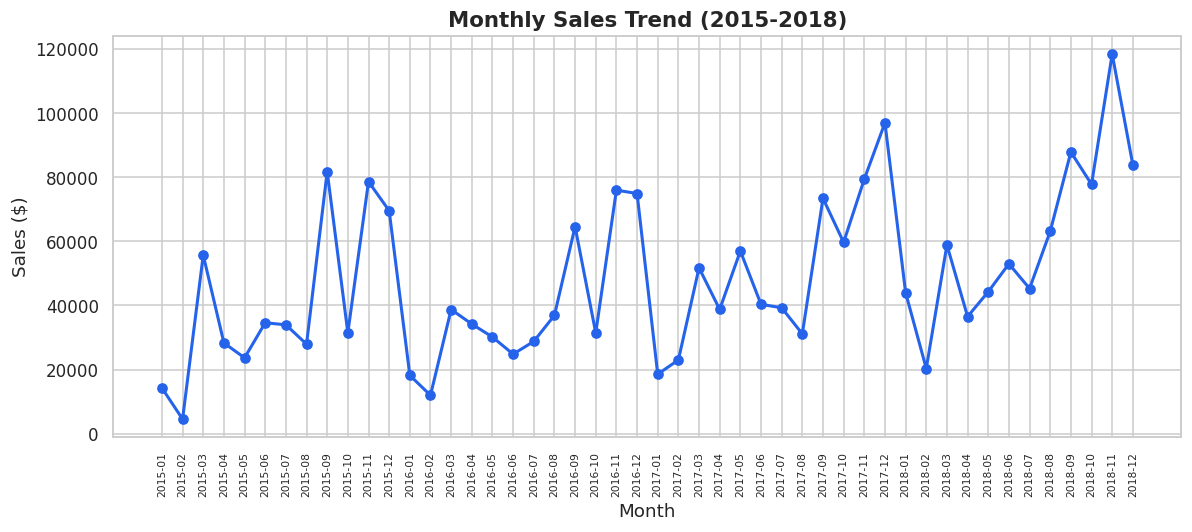

In [6]:
monthly_sales = df.groupby("Order Month").agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique")
).reset_index().sort_values("Order Month")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_sales["Order Month"], monthly_sales["Sales"], marker="o", color="#2563eb", linewidth=2)
ax.set_title("Monthly Sales Trend (2015-2018)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Sales ($)")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


In [7]:
yearly_sales = df.groupby("Order Year").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")).reset_index()
yearly_sales["YoY Growth %"] = yearly_sales["Sales"].pct_change() * 100
yearly_sales


,Order Year,Sales,Profit,YoY Growth %
0,2015,"484,247.50","49,543.97",NaN
1,2016,"470,532.51","61,618.60",-2.83
2,2017,"609,205.60","81,795.17",29.47
3,2018,"733,215.26","93,439.27",20.36


## 4. Product Performance

In [8]:
category_perf = df.groupby("Category").agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique")
).reset_index().sort_values("Sales", ascending=False)
category_perf["Profit Margin %"] = (category_perf["Profit"] / category_perf["Sales"]) * 100
category_perf


,Category,Sales,Profit,Orders,Profit Margin %
2,Technology,"836,154.03","145,454.95",1544,17.40
0,Furniture,"741,999.80","18,451.27",1764,2.49
1,Office Supplies,"719,047.03","122,490.80",3742,17.04


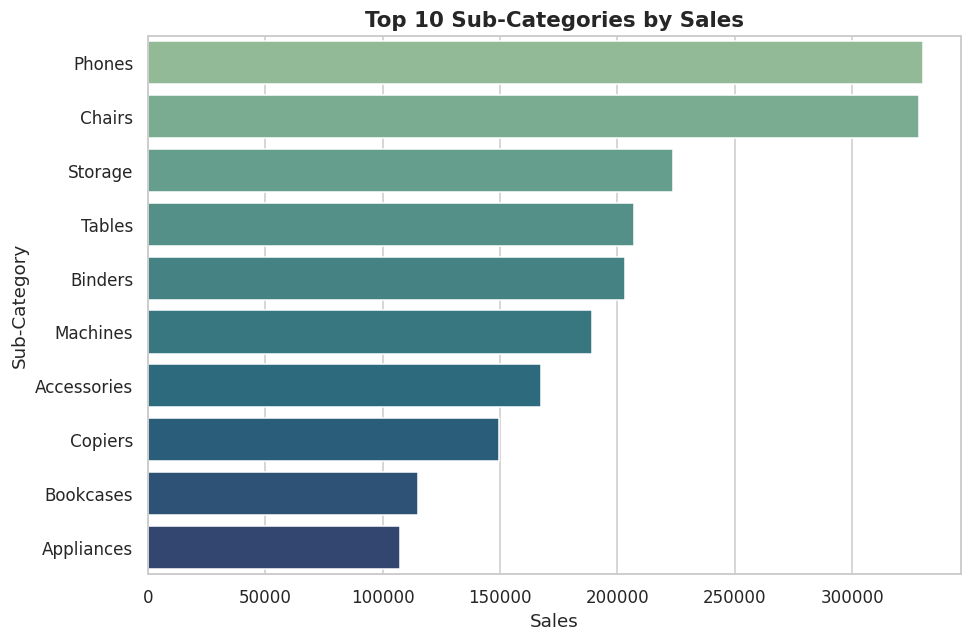

,Sub-Category,Sales,Profit,Quantity
13,Phones,"330,007.05","44,515.73","3,289.00"
5,Chairs,"328,449.10","26,590.17","2,356.00"
14,Storage,"223,843.61","21,278.83","3,158.00"
16,Tables,"206,965.53","-17,725.48","1,241.00"
3,Binders,"203,412.73","30,221.76","5,974.00"
11,Machines,"189,238.63","3,384.76",440.00
0,Accessories,"167,380.32","41,936.64","2,976.00"
6,Copiers,"149,528.03","55,617.82",234.00
4,Bookcases,"114,880.00","-3,472.56",868.00
1,Appliances,"107,532.16","18,138.01","1,729.00"


In [9]:
subcat_perf = df.groupby("Sub-Category").agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum"), Quantity=("Quantity", "sum")
).reset_index().sort_values("Sales", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=subcat_perf.head(10), y="Sub-Category", x="Sales", hue="Sub-Category",
            palette="crest", legend=False, ax=ax)
ax.set_title("Top 10 Sub-Categories by Sales", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

subcat_perf


In [10]:
# Sub-categories LOSING money - critical business insight
subcat_perf.sort_values("Profit").head(5)


,Sub-Category,Sales,Profit,Quantity
16,Tables,"206,965.53","-17,725.48","1,241.00"
4,Bookcases,"114,880.00","-3,472.56",868.00
15,Supplies,"46,673.54","-1,189.10",647.00
8,Fasteners,"3,024.28",949.52,914.00
11,Machines,"189,238.63","3,384.76",440.00


In [11]:
top_products = df.groupby("Product Name").agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum"), Quantity=("Quantity", "sum")
).reset_index().sort_values("Sales", ascending=False).head(15)
top_products


,Product Name,Sales,Profit,Quantity
404,Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20.00
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,"27,453.38","7,753.04",31.00
444,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08",6.00
786,HON 5400 Series Task Chairs for Big and Tall,"21,870.58",0.00,39.00
686,GBC DocuBind TL300 Electric Binding System,"19,823.48","2,233.51",37.00
688,GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50",760.98,48.00
805,Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38.00
787,HP Designjet T520 Inkjet Large Format Printer ...,"18,374.90","4,094.98",12.00
683,GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27.00
813,High Speed Automatic Electric Letter Opener,"17,030.31",-262.00,11.00


## 5. Regional Sales Analysis

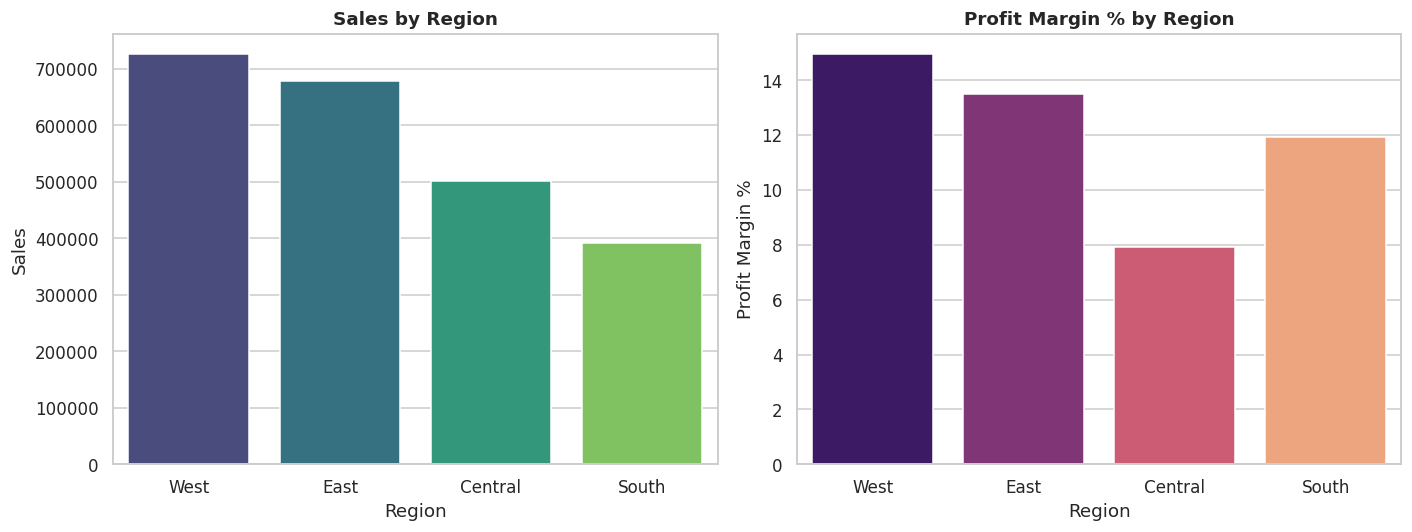

,Region,Sales,Profit,Orders,Customers,Profit Margin %
3,West,"725,457.82","108,418.45",1611,686,14.94
1,East,"678,781.24","91,522.78",1401,674,13.48
0,Central,"501,239.89","39,706.36",1175,629,7.92
2,South,"391,721.91","46,749.43",822,512,11.93


In [12]:
regional_perf = df.groupby("Region").agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique"),
    Customers=("Customer ID", "nunique")
).reset_index().sort_values("Sales", ascending=False)
regional_perf["Profit Margin %"] = (regional_perf["Profit"] / regional_perf["Sales"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=regional_perf, x="Region", y="Sales", hue="Region", legend=False, palette="viridis", ax=axes[0])
axes[0].set_title("Sales by Region", fontweight="bold")
sns.barplot(data=regional_perf, x="Region", y="Profit Margin %", hue="Region", legend=False, palette="magma", ax=axes[1])
axes[1].set_title("Profit Margin % by Region", fontweight="bold")
plt.tight_layout()
plt.show()

regional_perf


In [13]:
state_perf = df.groupby("State").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")).reset_index()
state_perf.sort_values("Sales", ascending=False).head(10)


,State,Sales,Profit
3,California,"457,687.63","76,381.39"
30,New York,"310,876.27","74,038.55"
41,Texas,"170,188.05","-25,729.36"
45,Washington,"138,641.27","33,402.65"
36,Pennsylvania,"116,511.91","-15,559.96"
8,Florida,"89,473.71","-3,399.30"
11,Illinois,"80,166.10","-12,607.89"
33,Ohio,"78,258.14","-16,971.38"
20,Michigan,"76,269.61","24,463.19"
44,Virginia,"70,636.72","18,597.95"


## 6. Customer Purchasing Behavior

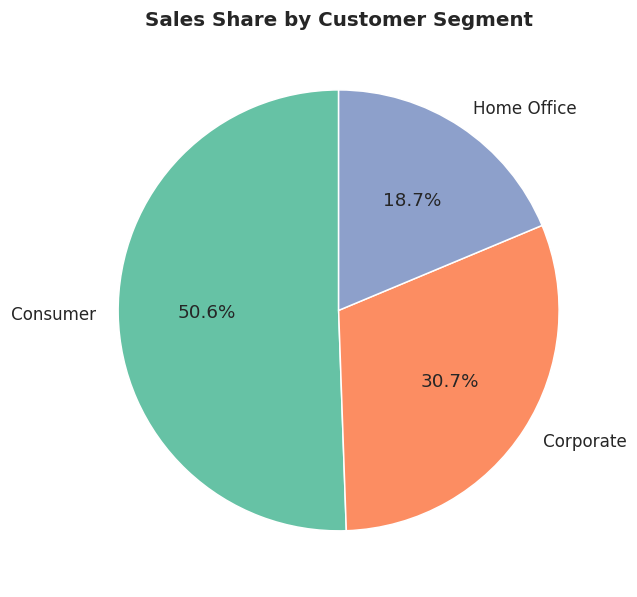

,Segment,Sales,Profit,Customers,Orders,Avg Order Value
0,Consumer,"1,161,401.34","134,119.21",409,2586,449.11
1,Corporate,"706,146.37","91,979.13",236,1514,466.41
2,Home Office,"429,653.15","60,298.68",148,909,472.67


In [14]:
segment_perf = df.groupby("Segment").agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum"), Customers=("Customer ID", "nunique"),
    Orders=("Order ID", "nunique")
).reset_index().sort_values("Sales", ascending=False)
segment_perf["Avg Order Value"] = segment_perf["Sales"] / segment_perf["Orders"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(segment_perf["Sales"], labels=segment_perf["Segment"], autopct="%1.1f%%",
       colors=sns.color_palette("Set2"), startangle=90)
ax.set_title("Sales Share by Customer Segment", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

segment_perf


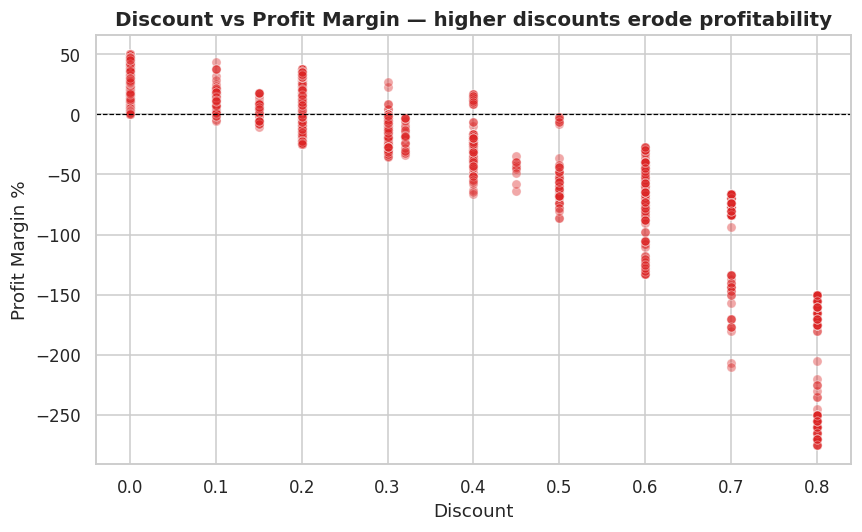

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="Discount", y="Profit Margin %", alpha=0.4, ax=ax, color="#dc2626")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Discount vs Profit Margin — higher discounts erode profitability", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [16]:
top_customers = df.groupby("Customer Name").agg(
    Sales=("Sales", "sum"), Orders=("Order ID", "nunique"), Profit=("Profit", "sum")
).reset_index().sort_values("Sales", ascending=False).head(10)
top_customers


,Customer Name,Sales,Orders,Profit
686,Sean Miller,"25,043.05",5,"-1,980.74"
730,Tamara Chand,"19,052.22",5,"8,981.32"
622,Raymond Buch,"15,117.34",6,"6,976.10"
757,Tom Ashbrook,"14,595.62",4,"4,703.79"
6,Adrian Barton,"14,473.57",10,"5,444.81"
441,Ken Lonsdale,"14,175.23",12,806.86
671,Sanjit Chand,"14,142.33",9,"5,757.41"
334,Hunter Lopez,"12,873.30",6,"5,622.43"
672,Sanjit Engle,"12,209.44",11,"2,650.68"
156,Christopher Conant,"12,129.07",5,"2,177.05"


## 7. Key Business Insights

1. **Revenue is growing strongly** — sales rose from ~$484K (2015) to ~$733K (2018), a 20%+ YoY jump in the final year, with a clear Q4 seasonal spike every year (holiday shopping).
2. **Tables are a hidden loss-maker** — the Tables sub-category generates over $200K in sales but posts a **negative** overall profit, driven by heavy discounting.
3. **Deep discounts destroy margin** — profit margin trends toward zero or negative once discounts exceed ~20%, visible clearly in the discount-vs-margin scatter plot.
4. **West and East regions drive profitability** — they lead in both sales and profit margin (~15% and ~13%), while Central lags at under 8% margin despite solid sales volume.
5. **Consumer segment dominates volume**, but Home Office customers have the highest average order value (~$473), suggesting an upsell opportunity there.
6. **Phones and Chairs are the top revenue sub-categories**, and both remain healthily profitable — good candidates for continued marketing investment.

### Recommendations
- Cap discounts on Tables and Bookcases, or renegotiate supplier costs — they are actively losing money.
- Investigate Central region's cost/fulfillment structure to close the margin gap with West/East.
- Target Home Office segment with higher-value bundles given their strong AOV.
- Double down on Q4 promotional planning given the consistent seasonal demand spike.
